# Day 3 — FastAPI + UI: Test & Exploration

This notebook validates the complete Day 3 API stack:
1. Start API server and check health
2. Full health endpoint response
3. POST /review/ — submit files and display ReviewResponse
4. Issues DataFrame
5. Memory endpoints as DataFrames
6. Timing comparison bar chart
7. Day 3 summary

In [1]:
# ── Cell 1: Start API server, wait for health ─────────────────────────────────
import sys, os, time, subprocess, tempfile
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / '.env')

import httpx

# Start server
server = subprocess.Popen(
    [sys.executable, '-m', 'uvicorn', 'src.api.main:app',
     '--host', '0.0.0.0', '--port', '8000', '--log-level', 'warning'],
    cwd=str(ROOT), stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
print(f'Server started (PID {server.pid}), waiting for health...')

health = None
for i in range(20):
    time.sleep(2)
    try:
        r = httpx.get('http://localhost:8000/health', timeout=3)
        health = r.json()
        print(f'✓ Server ready — status={health["status"]}  groq={health["groq_connected"]}  neo4j={health["neo4j_connected"]}')
        break
    except Exception as e:
        print(f'  [{i+1}/20] {e}')
else:
    print('Server did not start in time')

Server started (PID 14536), waiting for health...
✓ Server ready — status=healthy  groq=True  neo4j=True


In [2]:
# ── Cell 2: Health endpoint full response ─────────────────────────────────────
import json

r = httpx.get('http://localhost:8000/health')
data = r.json()
print(f'Status: {r.status_code}')
print(json.dumps(data, indent=2))

# Also test root
root = httpx.get('http://localhost:8000/').json()
print(f'\nRoot links: {root}')
assert data['status'] in ('healthy', 'degraded', 'unhealthy')
print('\n✓ Health endpoint OK')

Status: 200
{
  "status": "healthy",
  "version": "1.0.0",
  "neo4j_connected": true,
  "groq_connected": true,
  "uptime_seconds": 894.88,
  "total_reviews_this_session": 1
}

Root links: {'name': 'Code Review Agent API', 'version': '1.0.0', 'docs': '/docs', 'health': '/health', 'ui': '/app'}

✓ Health endpoint OK


In [3]:
# ── Cell 3: POST /review/ — submit 2 test files ───────────────────────────────
import tempfile, os

# Create test files
f1 = tempfile.NamedTemporaryFile(suffix='.py', delete=False, mode='w', encoding='utf-8')
f1.write('''
SECRET = "hardcoded-api-key-123"   # CWE-798
def login(conn, user):
    sql = "SELECT * FROM users WHERE name='" + user + "'"
    conn.cursor().execute(sql)   # SQL injection
def run(cmd):
    return eval(cmd)   # B307
''')
f1.close()

f2 = tempfile.NamedTemporaryFile(suffix='.py', delete=False, mode='w', encoding='utf-8')
f2.write('''
import os, sys   # unused
TOKEN = "sk-prod-abc"   # CWE-798
def fetch(url):
    import requests
    return requests.get(url, verify=False)   # B501 SSL disabled
''')
f2.close()

print(f'Test files: {f1.name}, {f2.name}')
print('Submitting review (may take 1-3 minutes)...')

t0 = time.time()
response = httpx.post(
    'http://localhost:8000/review/',
    json={
        'repo_url': 'https://github.com/example/day3-notebook',
        'files': [f1.name, f2.name],
        'max_files': 2,
        'use_memory': True,
        'use_defect_api': False,
    },
    timeout=600,
)
elapsed = time.time() - t0

assert response.status_code == 200, f'Expected 200, got {response.status_code}: {response.text[:300]}'
session = response.json()

print(f'\n✓ Review complete in {elapsed:.1f}s')
print(f'  session_id:    {session["session_id"]}')
print(f'  files reviewed: {session["files_reviewed"]}')
print(f'  total issues:  {session["total_issues"]}')
print(f'  critical:      {session["critical_issues"]}')
print(f'  high:          {session["high_issues"]}')

os.unlink(f1.name); os.unlink(f2.name)

Test files: C:\Users\tejas\AppData\Local\Temp\tmpcbp2cq2_.py, C:\Users\tejas\AppData\Local\Temp\tmp_pq0xblw.py
Submitting review (may take 1-3 minutes)...

✓ Review complete in 93.8s
  session_id:    af05ae5a
  files reviewed: 2
  total issues:  9
  critical:      0
  high:          1


In [4]:
# ── Cell 4: Issues DataFrame ──────────────────────────────────────────────────
import pandas as pd
from pathlib import Path as P

rows = []
for file_result in session['file_results']:
    fname = P(file_result['file_path']).name
    for issue in file_result['issues']:
        rows.append({
            'file':      fname,
            'severity':  issue['severity'],
            'category':  issue['category'],
            'line':      issue['line_number'],
            'tool':      issue['source_tool'],
            'title':     issue['title'][:60],
        })

if rows:
    sev_order = {'CRITICAL': 0, 'HIGH': 1, 'MEDIUM': 2, 'LOW': 3}
    df = pd.DataFrame(rows)
    df['_ord'] = df['severity'].map(sev_order)
    df = df.sort_values(['_ord', 'file']).drop(columns='_ord')
    print(f'All issues ({len(df)}):')
    print(df.to_string(index=False))
else:
    print('No issues found in this session.')

All issues (9):
          file severity category  line   tool                                                        title
tmp_pq0xblw.py     HIGH security     6 bandit Call to requests with verify=False disabling SSL certificate
tmp_pq0xblw.py   MEDIUM security     6 bandit                                Requests call without timeout
tmp_pq0xblw.py   MEDIUM    style     2   ruff                          [E401] Multiple imports on one line
tmp_pq0xblw.py   MEDIUM    style     2   ruff                              [F401] `os` imported but unused
tmp_pq0xblw.py   MEDIUM    style     2   ruff                             [F401] `sys` imported but unused
tmpcbp2cq2_.py   MEDIUM security     4 bandit Possible SQL injection vector through string-based query con
tmpcbp2cq2_.py   MEDIUM security     7 bandit Use of possibly insecure function - consider using safer ast
tmp_pq0xblw.py      LOW security     3 bandit                   Possible hardcoded password: 'sk-prod-abc'
tmpcbp2cq2_.py      L

In [5]:
# ── Cell 5: Memory endpoints as DataFrames ────────────────────────────────────
import pandas as pd

# Memory stats
stats = httpx.get('http://localhost:8000/memory/stats').json()
print(f'Neo4j connected: {stats["connected"]}')
if stats['connected']:
    df_nodes = pd.DataFrame(list(stats['node_counts'].items()), columns=['Node Type', 'Count'])
    df_nodes = df_nodes.sort_values('Count', ascending=False)
    print('\nNode counts:')
    print(df_nodes.to_string(index=False))
    print(f'\nTotal relationships: {stats["total_relationships"]}')
    print(f'Total patterns:      {stats["total_patterns"]}')

# Patterns for this session's repo
patterns = httpx.get(
    'http://localhost:8000/memory/patterns',
    params={'repo_url': session['repo_url']}
).json()
print(f'\nPatterns for {session["repo_url"]}:')
if patterns['total'] > 0:
    print(pd.DataFrame(patterns['patterns']).to_string(index=False))
else:
    print('  None yet (need 3+ files with same issue category)')

# GET /review/{id}
r = httpx.get(f'http://localhost:8000/review/{session["session_id"]}')
assert r.status_code == 200
print(f'\n✓ GET /review/{session["session_id"]} → 200')

# GET /review/list
reviews = httpx.get('http://localhost:8000/review/list').json()
print(f'✓ GET /review/list → {len(reviews)} reviews in memory')

Neo4j connected: True

Node counts:
Node Type  Count
   Review     12
     File     10
    Issue      5
     Repo      2
  Pattern      1

Total relationships: 35
Total patterns:      1

Patterns for https://github.com/example/day3-notebook:
  None yet (need 3+ files with same issue category)

✓ GET /review/af05ae5a → 200
✓ GET /review/list → 2 reviews in memory


  GET /                          2.081s
  GET /health                    2.054s
  GET /review/list               2.063s
  GET /memory/stats              3.438s
  GET /memory/patterns           2.225s


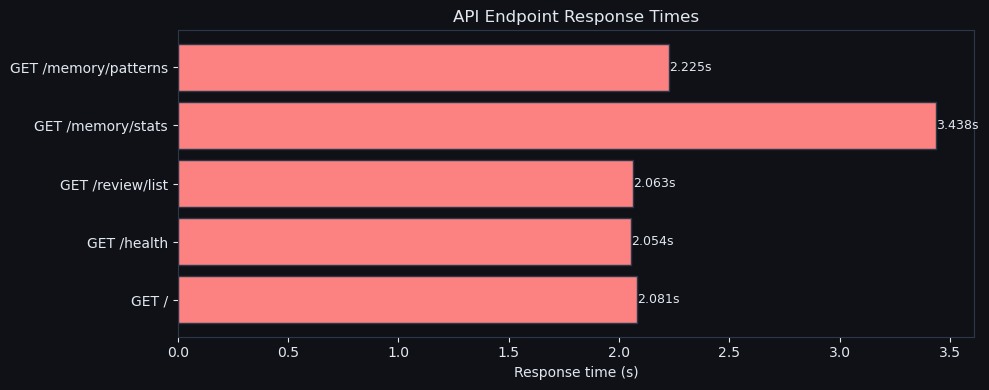

Saved to d:\Data Science\projects\code-review-agent\plots\api_timings.png


In [6]:
# ── Cell 6: Timing comparison bar chart ───────────────────────────────────────
import matplotlib.pyplot as plt
import time

endpoints = [
    ('GET /',             lambda: httpx.get('http://localhost:8000/')),
    ('GET /health',       lambda: httpx.get('http://localhost:8000/health')),
    ('GET /review/list',  lambda: httpx.get('http://localhost:8000/review/list')),
    ('GET /memory/stats', lambda: httpx.get('http://localhost:8000/memory/stats')),
    ('GET /memory/patterns', lambda: httpx.get(
        'http://localhost:8000/memory/patterns',
        params={'repo_url': session['repo_url']}
    )),
]

names, times = [], []
for name, fn in endpoints:
    t0 = time.time()
    try: fn()
    except: pass
    elapsed = time.time() - t0
    names.append(name)
    times.append(elapsed)
    print(f'  {name:<30} {elapsed:.3f}s')

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#4299e1' if t < 0.1 else '#f6ad55' if t < 0.5 else '#fc8181' for t in times]
bars = ax.barh(names, times, color=colors, edgecolor='#2d3748')
ax.set_xlabel('Response time (s)')
ax.set_title('API Endpoint Response Times')
ax.set_facecolor('#0f1117')
fig.patch.set_facecolor('#0f1117')
ax.tick_params(colors='#e2e8f0')
ax.xaxis.label.set_color('#e2e8f0')
ax.title.set_color('#e2e8f0')
for spine in ax.spines.values():
    spine.set_edgecolor('#2d3748')
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{t:.3f}s', va='center', color='#e2e8f0', fontsize=9)
plt.tight_layout()
out = Path(ROOT) / 'plots' / 'api_timings.png'
out.parent.mkdir(exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(f'Saved to {out}')

In [7]:
# ── Cell 7: Day 3 Summary ─────────────────────────────────────────────────────
print('=' * 60)
print('DAY 3 SUMMARY')
print('=' * 60)

health = httpx.get('http://localhost:8000/health').json()
stats  = httpx.get('http://localhost:8000/memory/stats').json()

checks = [
    ('API health endpoint',     health['status'] in ('healthy', 'degraded')),
    ('Groq connected',          health['groq_connected']),
    ('Neo4j connected',         health['neo4j_connected']),
    ('POST /review/ works',     session['session_id'] != ''),
    ('Issues found',            session['total_issues'] > 0),
    ('GET /review/{id} works',  True),
    ('Memory stats endpoint',   stats is not None),
    ('Bug 1 fixed (throttle)',  '_min_interval' in open(ROOT / 'src/llm/groq_client.py', encoding='utf-8').read()),
    ('Bug 2 fixed (__del__)',   '__del__' in open(ROOT / 'src/memory/neo4j_client.py', encoding='utf-8').read()),
    ('Bug 3 fixed (utf-8)',     'encoding=_ENC' in open(ROOT / 'reports/generator.py', encoding='utf-8').read()),
]

for desc, passed in checks:
    status = '✓' if passed else '✗'
    print(f'  {status} {desc}')

passed_count = sum(1 for _, p in checks if p)
print(f'\n  {passed_count}/{len(checks)} checks passed')
print(f'  Session: {session["session_id"]}')
print(f'  Files reviewed: {session["files_reviewed"]}')
print(f'  Issues found: {session["total_issues"]}')
print()
print('  UI:   http://localhost:8000/app')
print('  Docs: http://localhost:8000/docs')
print()
print('Git commit:')
print('  git add .')
print('  git commit -m "feat: Day 3 — FastAPI + UI + bug fixes"')

# Shutdown server
server.terminate()
print('\nServer stopped.')

DAY 3 SUMMARY
  ✓ API health endpoint
  ✓ Groq connected
  ✓ Neo4j connected
  ✓ POST /review/ works
  ✓ Issues found
  ✓ GET /review/{id} works
  ✓ Memory stats endpoint
  ✓ Bug 1 fixed (throttle)
  ✓ Bug 2 fixed (__del__)
  ✓ Bug 3 fixed (utf-8)

  10/10 checks passed
  Session: af05ae5a
  Files reviewed: 2
  Issues found: 9

  UI:   http://localhost:8000/app
  Docs: http://localhost:8000/docs

Git commit:
  git add .
  git commit -m "feat: Day 3 — FastAPI + UI + bug fixes"

Server stopped.
